In [1]:
# 1. Install TabNet
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.6 MB/s eta 0:00:00


In [2]:
# 2. Import Libraries
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from pytorch_tabnet.tab_model import TabNetClassifier

In [3]:
# 3. Load Dataset
df = pd.read_csv("/kaggle/input/datasets/dhivyeshrk/diseases-and-symptoms-dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv")

print(df.head())

         diseases  anxiety and nervousness  depression  shortness of breath  \
0  panic disorder                        1           0                    1   
1  panic disorder                        0           0                    1   
2  panic disorder                        1           1                    1   
3  panic disorder                        1           0                    0   
4  panic disorder                        1           1                    0   

   depressive or psychotic symptoms  sharp chest pain  dizziness  insomnia  \
0                                 1                 0          0         0   
1                                 1                 0          1         1   
2                                 1                 0          1         1   
3                                 1                 0          1         1   
4                                 0                 0          0         1   

   abnormal involuntary movements  chest tightness  ... 

In [4]:
# 4. Split Features and Target

# Features and target
X = df.drop("diseases", axis=1)
y = df["diseases"]

In [5]:
# 5. Encode Target Labels

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

num_classes = len(np.unique(y))
print("Number of diseases:", num_classes)

Number of diseases: 773


In [11]:
# Remove very rare diseases
# Step 1: Convert y to pandas
y = pd.Series(y)

# Step 2: Remove rare classes
counts = y.value_counts()
valid = counts[counts >= 2].index

mask = y.isin(valid)
X = X[mask]
y = y[mask]

print("Remaining classes:", len(valid))

Remaining classes: 754


In [12]:
# 6. Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
# 7. Convert to NumPy Arrays

import numpy as np

X_train = np.asarray(X_train)
X_test = np.asarray(X_test)
y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

In [14]:
# 8. Build TabNet Model

import torch

tabnet_model = TabNetClassifier(
    n_d=64,
    n_a=64,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type='entmax'
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [15]:
# 9. Train Model

tabnet_model.fit(
    X_train=X_train,
    y_train=y_train,
    eval_set=[(X_test, y_test)],
    eval_metric=['accuracy'],
    max_epochs=50,
    patience=10,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

epoch 0  | loss: 3.99367 | val_0_accuracy: 0.31663 |  0:00:13s
epoch 1  | loss: 1.15353 | val_0_accuracy: 0.7474  |  0:00:27s
epoch 2  | loss: 0.65076 | val_0_accuracy: 0.82205 |  0:00:40s
epoch 3  | loss: 0.52789 | val_0_accuracy: 0.83528 |  0:00:53s
epoch 4  | loss: 0.47102 | val_0_accuracy: 0.83797 |  0:01:06s
epoch 5  | loss: 0.445   | val_0_accuracy: 0.84249 |  0:01:20s
epoch 6  | loss: 0.42381 | val_0_accuracy: 0.84253 |  0:01:33s
epoch 7  | loss: 0.41239 | val_0_accuracy: 0.84919 |  0:01:46s
epoch 8  | loss: 0.40518 | val_0_accuracy: 0.85113 |  0:01:59s
epoch 9  | loss: 0.3942  | val_0_accuracy: 0.84724 |  0:02:13s
epoch 10 | loss: 0.38738 | val_0_accuracy: 0.85129 |  0:02:26s
epoch 11 | loss: 0.38445 | val_0_accuracy: 0.84743 |  0:02:39s
epoch 12 | loss: 0.38243 | val_0_accuracy: 0.85389 |  0:02:53s
epoch 13 | loss: 0.37114 | val_0_accuracy: 0.85103 |  0:03:06s
epoch 14 | loss: 0.36623 | val_0_accuracy: 0.84919 |  0:03:20s
epoch 15 | loss: 0.36199 | val_0_accuracy: 0.85528 |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [16]:
# 10. Evaluate Model
y_pred = tabnet_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8552828736888997

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       0.94      1.00      0.97        81
           2       0.89      0.86      0.88        58
           3       0.80      1.00      0.89         4
           4       0.79      0.93      0.85        68
           5       0.75      1.00      0.86         6
           6       1.00      0.86      0.92         7
           7       0.74      0.82      0.78        17
           8       0.87      0.72      0.78        99
           9       0.83      0.77      0.80       182
          10       0.94      0.91      0.92       241
          11       0.74      0.81      0.77       243
          12       0.69      0.71      0.70       181
          13       0.50      1.00      0.67         2
          14       0.39      0.40      0.40        42
          15       0.99      0.96      0.97       182
          16       0.75    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [17]:
!pip install shap

  0%|          | 0/50 [00:00<?, ?it/s]

SHAP shape: (50, 377, 754)
X_shap shape: (50, 377)
SHAP Summary for abdominal aortic aneurysm


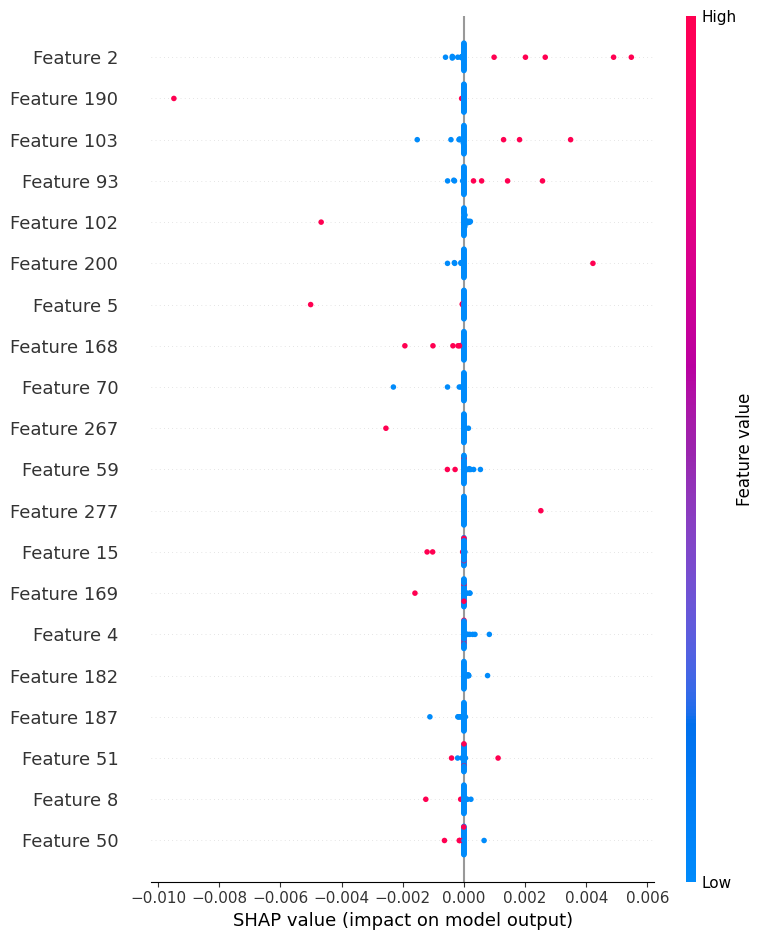

SHAP Summary for abdominal hernia


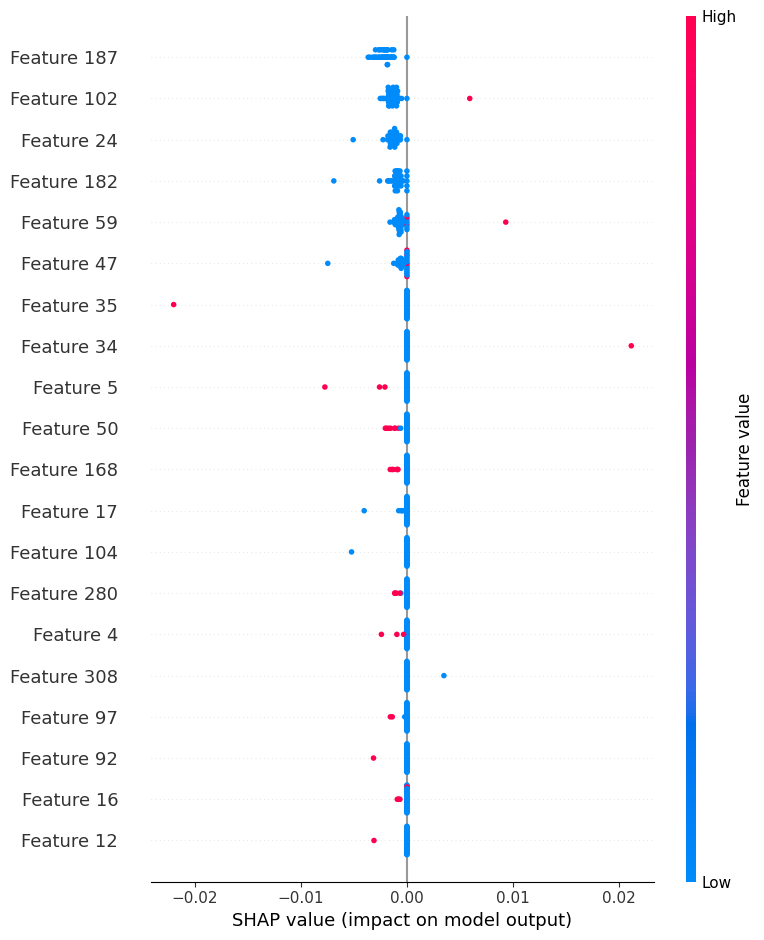

SHAP Summary for abscess of nose


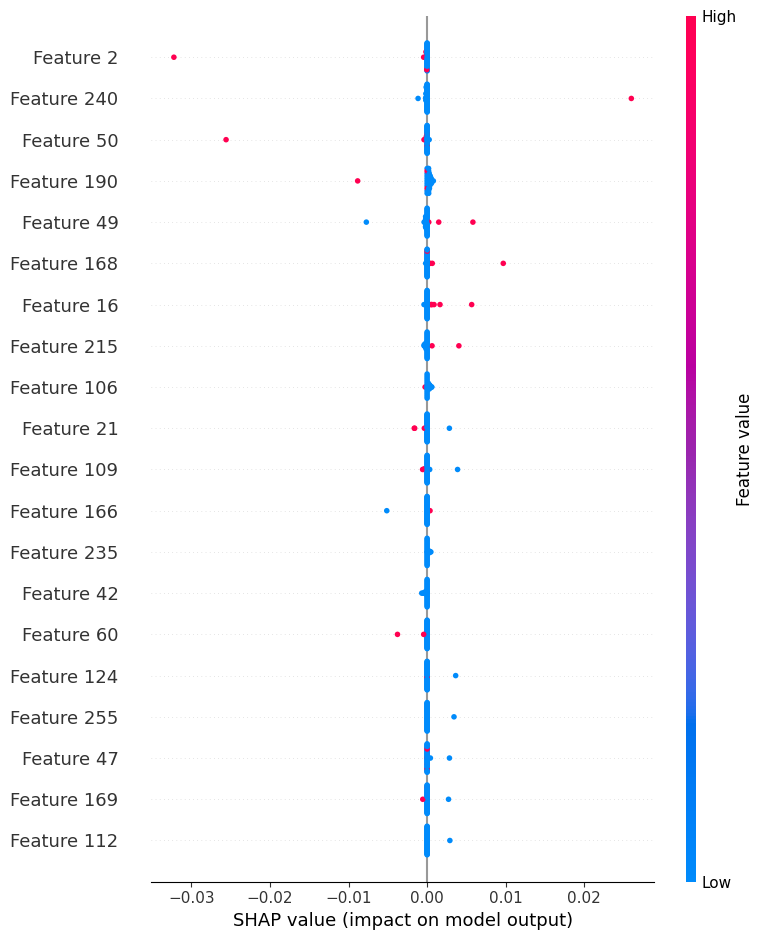

SHAP Summary for abscess of the lung


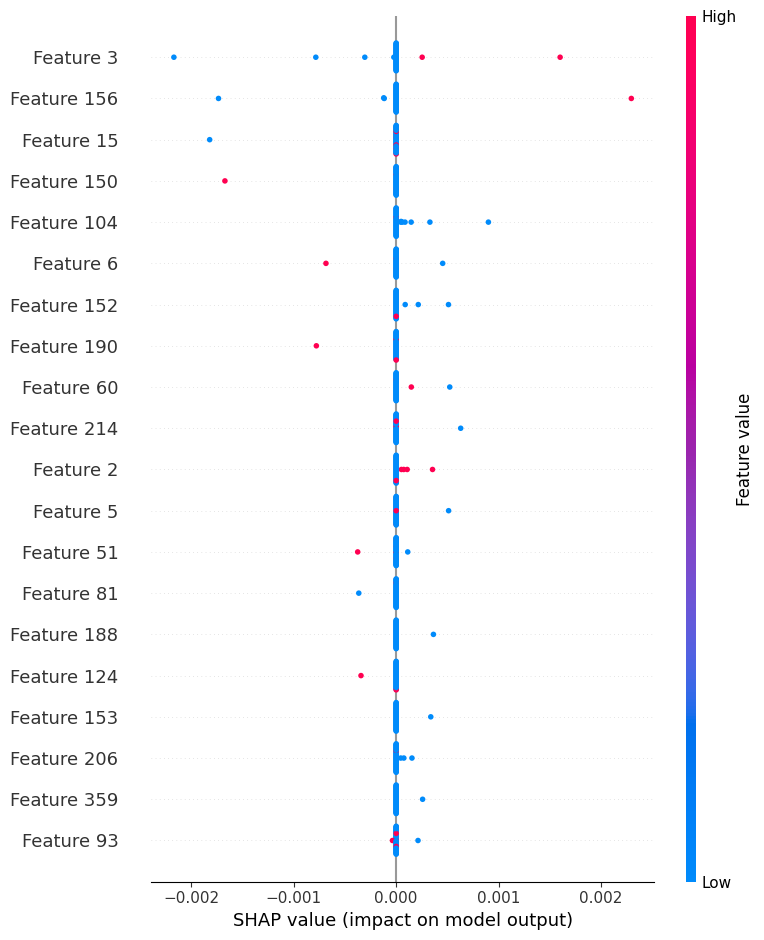

SHAP Summary for abscess of the pharynx


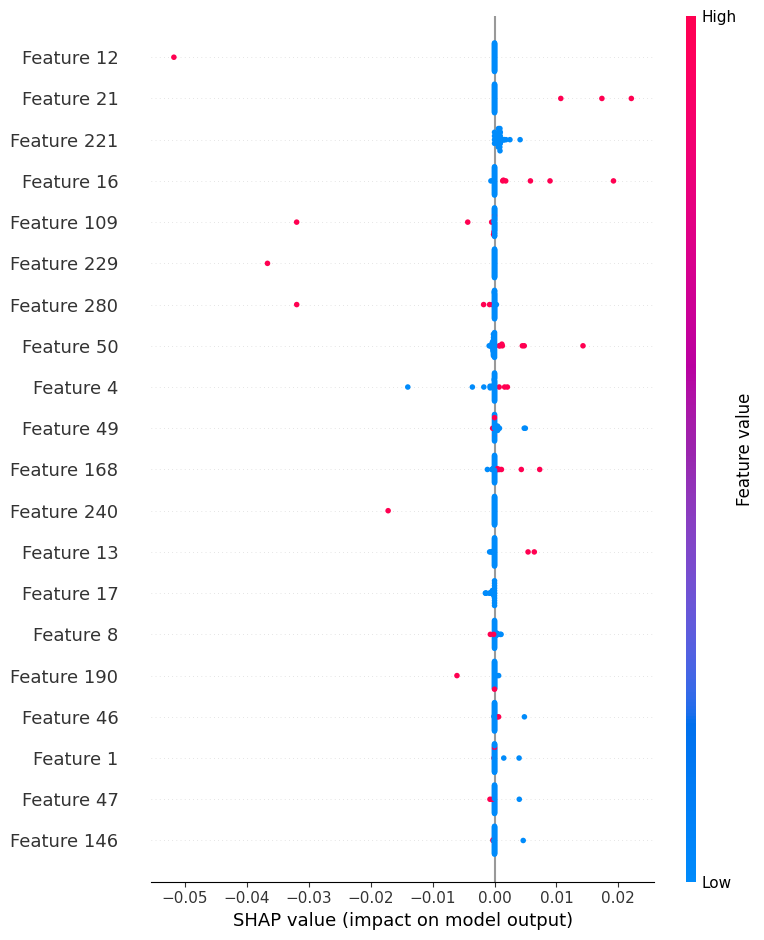

In [21]:
import shap
import numpy as np

# Convert to numpy
X_train_np = X_train.astype(np.float32)
X_test_np = X_test.astype(np.float32)

# Background samples
background = X_train_np[
    np.random.choice(X_train_np.shape[0], 100, replace=False)
]

# Prediction function
def predict_fn(data):
    return tabnet_model.predict_proba(data)

# KernelExplainer
explainer = shap.KernelExplainer(
    predict_fn,
    background
)

# Samples to explain
X_shap = X_test_np[:50]

# Compute SHAP values
shap_values = explainer.shap_values(X_shap)

# Fix feature names
feature_names = [f"Feature {i}" for i in range(X_shap.shape[1])]

# shap_values already numpy array
shap_array = shap_values

print("SHAP shape:", shap_array.shape)
print("X_shap shape:", X_shap.shape)

# Correct slicing: (samples, features, class)
for i, class_name in enumerate(label_encoder.classes_[:5]):
    
    print(f"SHAP Summary for {class_name}")
    
    shap.summary_plot(
        shap_array[:, :, i],
        X_shap,
        feature_names=feature_names
    )

In [22]:
# 11. Save Model
tabnet_model.save_model("tabnet_disease_model")
print("TabNet model saved successfully!")

Successfully saved model at tabnet_disease_model.zip
TabNet model saved successfully!
